In [1]:
# Lab 4: Regression Analysis Using Diabetes Dataset

# Name: Bilal Khalid

# Course: Advanced Big Data and Data Mining (MSCS-634-M20)

# Dataset: Diabetes Dataset (sklearn)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

df = pd.DataFrame(X, columns=diabetes.feature_names)

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [5]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [6]:
df.isnull().sum()

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

In [7]:
# No missing values were found in the Diabetes dataset. Therefore, no data cleaning was required.

In [8]:
X_simple = df[['bmi']]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("MAE =",mae)
print("MSE =",mse)
print("RMSE =",rmse)
print("R2 =",r2)

MAE = 52.25997644534553
MSE = 4061.8259284949268
RMSE = 63.73245584860925
R2 = 0.23335039815872138


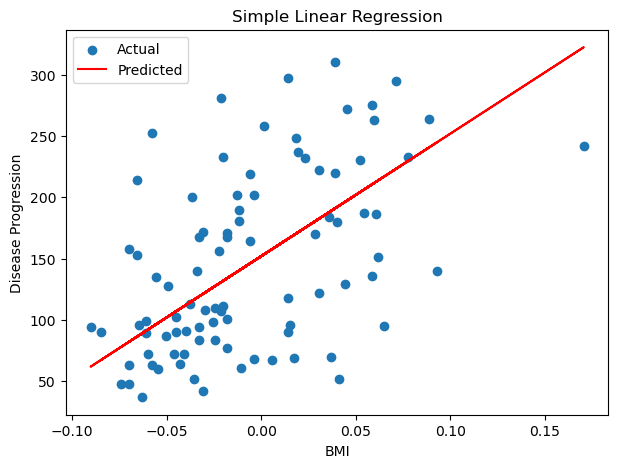

In [12]:
plt.figure(figsize=(7,5))

plt.scatter(X_test,y_test,label="Actual")

plt.plot(X_test,y_pred,color='red',label="Predicted")

plt.xlabel("BMI")
plt.ylabel("Disease Progression")

plt.title("Simple Linear Regression")

plt.legend()

plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

multiple_model = LinearRegression()

multiple_model.fit(X_train,y_train)

y_pred_multi = multiple_model.predict(X_test)

In [14]:
print("MAE =",mean_absolute_error(y_test,y_pred_multi))

print("MSE =",mean_squared_error(y_test,y_pred_multi))

print("RMSE =",np.sqrt(mean_squared_error(y_test,y_pred_multi)))

print("R2 =",r2_score(y_test,y_pred_multi))

MAE = 42.79409467959994
MSE = 2900.1936284934814
RMSE = 53.85344583676593
R2 = 0.4526027629719195


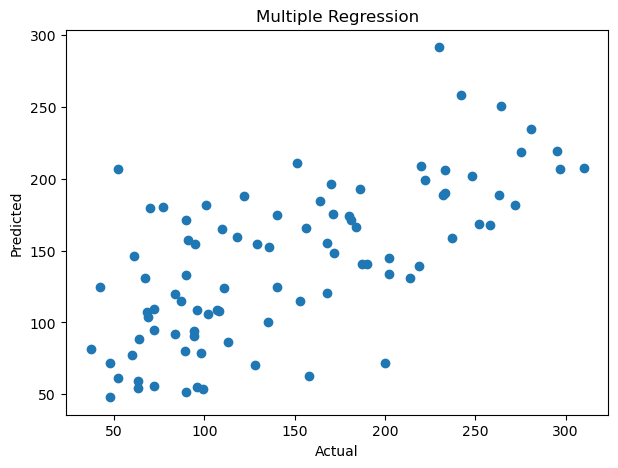

In [15]:
plt.figure(figsize=(7,5))

plt.scatter(y_test,y_pred_multi)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Multiple Regression")

plt.show()

In [28]:
poly2 = PolynomialFeatures(degree=2)

X_poly2 = poly2.fit_transform(X)

X_train_poly2, X_test_poly2, y_train, y_test = train_test_split(
    X_poly2,
    y,
    test_size=0.2,
    random_state=42
)

poly_model2 = LinearRegression()

poly_model2.fit(X_train_poly2, y_train)

y_pred_poly2 = poly_model2.predict(X_test_poly2)

# Metrics
mae_poly2 = mean_absolute_error(y_test, y_pred_poly2)
mse_poly2 = mean_squared_error(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mse_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

In [29]:
poly3 = PolynomialFeatures(degree=3)

X_poly3 = poly3.fit_transform(X)

X_train_poly3, X_test_poly3, y_train, y_test = train_test_split(
    X_poly3,
    y,
    test_size=0.2,
    random_state=42
)

poly_model3 = LinearRegression()

poly_model3.fit(X_train_poly3, y_train)

y_pred_poly3 = poly_model3.predict(X_test_poly3)

# Metrics
mae_poly3 = mean_absolute_error(y_test, y_pred_poly3)
mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
rmse_poly3 = np.sqrt(mse_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)

In [30]:
print("Degree 2")
print("MAE =", mae_poly2)
print("MSE =", mse_poly2)
print("RMSE =", rmse_poly2)
print("R2 =", r2_poly2)

print("\nDegree 3")
print("MAE =", mae_poly3)
print("MSE =", mse_poly3)
print("RMSE =", rmse_poly3)
print("R2 =", r2_poly3)

Degree 2
MAE = 43.58169325465254
MSE = 3096.0283073442774
RMSE = 55.641965344012405
R2 = 0.4156399336407991

Degree 3
MAE = 164.85389734396483
MSE = 82446.04875535943
RMSE = 287.13419990547874
R2 = -14.56128489117795


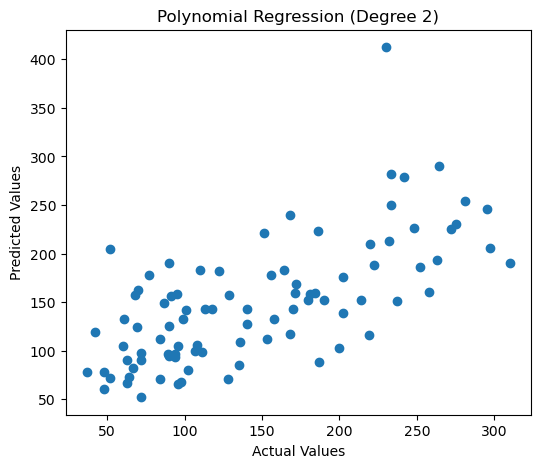

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_poly2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Polynomial Regression (Degree 2)")
plt.show()

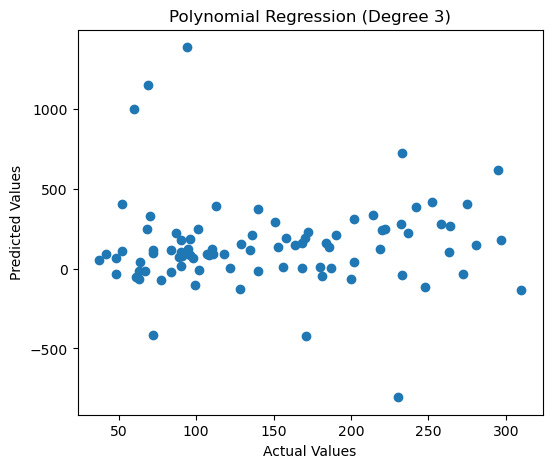

In [32]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_poly3)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Polynomial Regression (Degree 3)")
plt.show()

In [19]:
#Increasing polynomial degree increases model complexity. Higher degrees may lead to overfitting and reduced performance on test data.

In [34]:
ridge = Ridge(alpha=1)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [35]:
print("MAE =", mean_absolute_error(y_test, y_pred_ridge))
print("MSE =", mean_squared_error(y_test, y_pred_ridge))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 =", r2_score(y_test, y_pred_ridge))

MAE = 46.13885766697452
MSE = 3077.41593882723
RMSE = 55.47446204180109
R2 = 0.41915292635986545


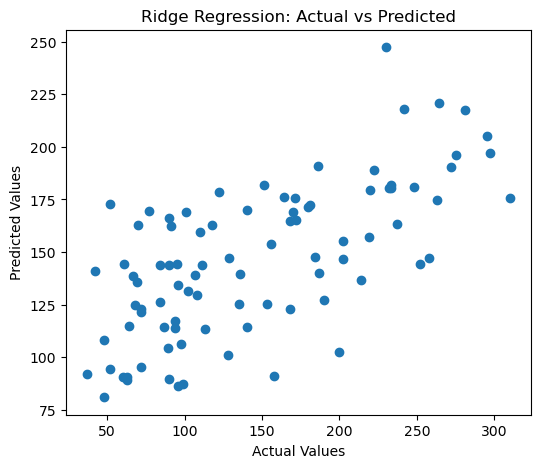

In [36]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_ridge)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Ridge Regression: Actual vs Predicted")

plt.show()

In [22]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train,y_train)

lasso_pred = lasso.predict(X_test)

In [23]:
print("MAE =",mean_absolute_error(y_test,lasso_pred))

print("MSE =",mean_squared_error(y_test,lasso_pred))

print("RMSE =",np.sqrt(mean_squared_error(y_test,lasso_pred)))

print("R2 =",r2_score(y_test,lasso_pred))

MAE = 42.85442771664998
MSE = 2798.1934851697188
RMSE = 52.897953506442185
R2 = 0.4718547867276227


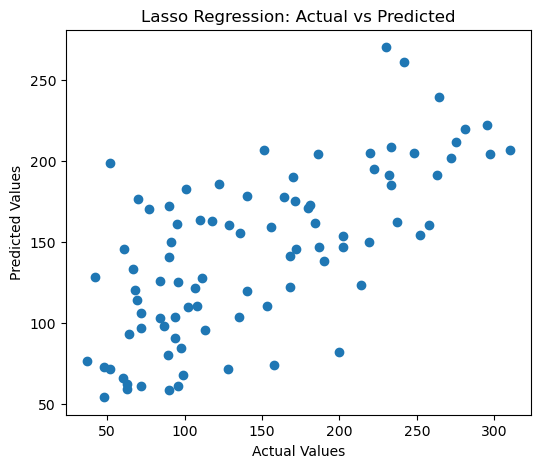

In [38]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, lasso_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Lasso Regression: Actual vs Predicted")

plt.show()

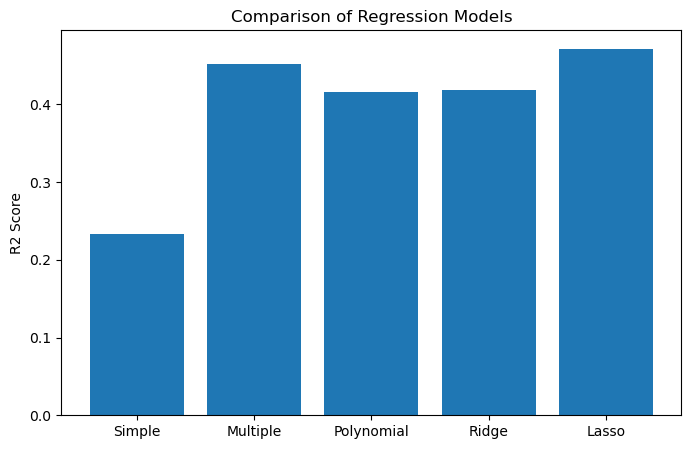

In [24]:
models = ['Simple','Multiple','Polynomial','Ridge','Lasso']

r2_scores = [
r2,
r2_score(y_test,y_pred_multi),
r2_score(y_test,y_pred_poly),
r2_score(y_test,ridge_pred),
r2_score(y_test,lasso_pred)
]

plt.figure(figsize=(8,5))

plt.bar(models,r2_scores)

plt.ylabel("R2 Score")

plt.title("Comparison of Regression Models")

plt.show()